<a href="https://colab.research.google.com/github/mwierciszewska/TensorFlow_lab/blob/main/NLP_Medical_Paper_Abstracts_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#download data - the PubMed 200k RCT dataset using clone in GitHub
#train to replicate papers https://arxiv.org/pdf/1612.05251 and then try to build a better model

In [2]:
!git clone https://github.com/Franck-Dernoncourt/pubmed-rct.git

Cloning into 'pubmed-rct'...
remote: Enumerating objects: 39, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 39 (delta 8), reused 5 (delta 5), pack-reused 25 (from 1)
Receiving objects: 100% (39/39), 177.08 MiB | 25.38 MiB/s, done.
Resolving deltas: 100% (15/15), done.
Updating files: 100% (13/13), done.


In [3]:
!ls pubmed-rct

PubMed_200k_RCT				       PubMed_20k_RCT_numbers_replaced_with_at_sign
PubMed_200k_RCT_numbers_replaced_with_at_sign  README.md
PubMed_20k_RCT


In [4]:
data_dir = "pubmed-rct/PubMed_20k_RCT/"

In [5]:
#preprocesiing text data

In [6]:
def get_lines(filename):
  with open(filename, 'r') as f:
    return f.readlines()

In [7]:
train_data = get_lines(data_dir+'train.txt')

In [8]:
train_data[:15]

['###24293578\n',
 'OBJECTIVE\tTo investigate the efficacy of 6 weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at 12 weeks in older adults with moderate to severe knee osteoarthritis ( OA ) .\n',
 'METHODS\tA total of 125 patients with primary knee OA were randomized 1:1 ; 63 received 7.5 mg/day of prednisolone and 62 received placebo for 6 weeks .\n',
 'METHODS\tOutcome measures included pain reduction and improvement in function scores and systemic inflammation markers .\n',
 'METHODS\tPain was assessed using the visual analog pain scale ( 0-100 mm ) .\n',
 'METHODS\tSecondary outcome measures included the Western Ontario and McMaster Universities Osteoarthritis Index scores , patient global assessment ( PGA ) of the severity of knee OA , and 6-min walk distance ( 6MWD ) .\n',
 'METHODS\tSerum levels of interleukin 1 ( IL-1 ) , IL-6 , tumor necrosis factor ( TNF )

In [9]:
def processing_text_data(filename):
  input_lines=get_lines(filename)
  abstract_ids=[]

  for line in input_lines:
    if line.startswith('###'):
      abstract_id=line
      abstract_ids.append(abstract_id)

  return abstract_ids

In [10]:
train_id = processing_text_data(data_dir+'train.txt')

In [11]:
def processing_text_data(filename):
  input_lines=get_lines(filename)
  abstract_lines=''
  abstract_sample=[]
  abstract_ids=[]

  for line in input_lines:
    if line.startswith('###'):
      abstract_id=line
      abstract_lines='' #reset

    elif line.isspace():
      abstract_line_split = abstract_lines.splitlines() #split into lines (\n)

      for abstract_line_number, abstract_line in enumerate(abstract_line_split):
        line_data={}
        target_text_split = abstract_line.split('\t')
        line_data['target'] = target_text_split[0]
        line_data['text'] = target_text_split[1]
        line_data['line_number'] = abstract_line_number
        line_data['total_lines'] = len(abstract_line_split)-1
        abstract_sample.append(line_data)

    else:
      abstract_lines += line
  return abstract_sample

In [12]:
%%time
train_data = processing_text_data(data_dir+'train.txt')
test_data = processing_text_data(data_dir+'test.txt')
valid_data = processing_text_data(data_dir+'dev.txt')
len(train_data), len(test_data), len(valid_data)

CPU times: user 573 ms, sys: 73.7 ms, total: 646 ms
Wall time: 1.2 s


(180040, 30135, 30212)

In [13]:
train_data[:20]

[{'target': 'OBJECTIVE',
  'text': 'To investigate the efficacy of 6 weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at 12 weeks in older adults with moderate to severe knee osteoarthritis ( OA ) .',
  'line_number': 0,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'A total of 125 patients with primary knee OA were randomized 1:1 ; 63 received 7.5 mg/day of prednisolone and 62 received placebo for 6 weeks .',
  'line_number': 1,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'Outcome measures included pain reduction and improvement in function scores and systemic inflammation markers .',
  'line_number': 2,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'Pain was assessed using the visual analog pain scale ( 0-100 mm ) .',
  'line_number': 3,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'Secondary outcome measures included the Weste

In [14]:
import pandas as pd

In [15]:
train_df = pd.DataFrame(train_data)
test_df = pd.DataFrame(test_data)
valid_df = pd.DataFrame(valid_data)

In [16]:
train_df.head(10)

,target,text,line_number,total_lines
0,OBJECTIVE,To investigate the efficacy of 6 weeks of dail...,0,11
1,METHODS,A total of 125 patients with primary knee OA w...,1,11
2,METHODS,Outcome measures included pain reduction and i...,2,11
3,METHODS,Pain was assessed using the visual analog pain...,3,11
4,METHODS,Secondary outcome measures included the Wester...,4,11
5,METHODS,"Serum levels of interleukin 1 ( IL-1 ) , IL-6 ...",5,11
6,RESULTS,There was a clinically relevant reduction in t...,6,11
7,RESULTS,The mean difference between treatment arms ( 9...,7,11
8,RESULTS,"Further , there was a clinically relevant redu...",8,11
9,RESULTS,These differences remained significant at 12 w...,9,11


In [17]:
train_df['target'].value_counts()

,count
target,
METHODS,59353
RESULTS,57953
CONCLUSIONS,27168
BACKGROUND,21727
OBJECTIVE,13839


<Axes: ylabel='Frequency'>

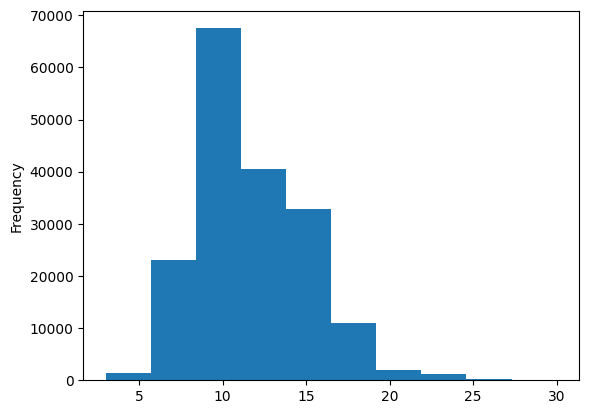

In [18]:
train_df['total_lines'].plot.hist()

In [19]:
train_text = train_df['text'].tolist()
test_text = test_df['text'].tolist()
valid_text = valid_df['text'].tolist()

In [20]:
train_text[:10]

['To investigate the efficacy of 6 weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at 12 weeks in older adults with moderate to severe knee osteoarthritis ( OA ) .',
 'A total of 125 patients with primary knee OA were randomized 1:1 ; 63 received 7.5 mg/day of prednisolone and 62 received placebo for 6 weeks .',
 'Outcome measures included pain reduction and improvement in function scores and systemic inflammation markers .',
 'Pain was assessed using the visual analog pain scale ( 0-100 mm ) .',
 'Secondary outcome measures included the Western Ontario and McMaster Universities Osteoarthritis Index scores , patient global assessment ( PGA ) of the severity of knee OA , and 6-min walk distance ( 6MWD ) .',
 'Serum levels of interleukin 1 ( IL-1 ) , IL-6 , tumor necrosis factor ( TNF ) - , and high-sensitivity C-reactive protein ( hsCRP ) were measured .',
 'There was

In [21]:
#Transform labels into numbers

In [22]:
from sklearn.preprocessing import OneHotEncoder

In [23]:
OHE = OneHotEncoder(sparse_output=False)

In [24]:
train_labels_ohe = OHE.fit_transform(train_df['target'].to_numpy().reshape(-1,1))

In [25]:
test_labels_ohe = OHE.transform(test_df['target'].to_numpy().reshape(-1,1))
valid_labels_ohe = OHE.transform(valid_df['target'].to_numpy().reshape(-1,1))

In [26]:
from sklearn.preprocessing import LabelEncoder

In [27]:
encoder = LabelEncoder()

In [28]:
train_labels = encoder.fit_transform(train_df['target'])
test_labels = encoder.transform(test_df['target'])
valid_labels = encoder.transform(valid_df['target'])

In [29]:
train_labels[:10]

array([3, 2, 2, 2, 2, 2, 4, 4, 4, 4])

In [30]:
print(type(train_labels))

<class 'numpy.ndarray'>


In [31]:
class_names = encoder.classes_

In [32]:
class_names

array(['BACKGROUND', 'CONCLUSIONS', 'METHODS', 'OBJECTIVE', 'RESULTS'],
      dtype=object)

In [33]:
num_classes = len(class_names)
num_classes

5

In [34]:
#building baseline model - TF-IDF

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

In [36]:
model_0 = Pipeline([
                    ('tf-idf', TfidfVectorizer()),
                    ('clf', MultinomialNB())
])

In [37]:
model_0.fit(train_text, train_labels)

Pipeline(steps=[('tf-idf', TfidfVectorizer()), ('clf', MultinomialNB())])

In [38]:
model_0.score(valid_text, valid_labels)

0.7317291142592347

In [39]:
baseline_pred = model_0.predict(valid_text)

In [40]:
!wget https://raw.githubusercontent.com/mwierciszewska/TensorFlow_lab/refs/heads/main/extras/helper_functions.py

--2025-04-09 11:09:03--  https://raw.githubusercontent.com/mwierciszewska/TensorFlow_lab/refs/heads/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10182 (9.9K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]   9.94K  --.-KB/s    in 0s      

2025-04-09 11:09:03 (28.2 MB/s) - ‘helper_functions.py’ saved [10182/10182]



In [41]:
from helper_functions import create_model_results

In [42]:
baseline_results = create_model_results(valid_labels, baseline_pred)
baseline_results

{'accuracy': 0.7317291142592347,
 'preciscion': 0.7315166696974572,
 'recall': 0.7317291142592347,
 'f1-score': 0.7058060715307974}

In [43]:
#transform text data

In [44]:
word_lens = [len(text.split()) for text in train_text]

In [45]:
import numpy as np

In [46]:
avg_word_len = np.mean(word_lens)

In [47]:
avg_word_len

np.float64(26.338435903132638)

In [48]:
#checking max
np.max(word_lens)

np.int64(296)

In [49]:
#checkin min
np.min(word_lens)

np.int64(1)

In [50]:
import matplotlib.pyplot as plt

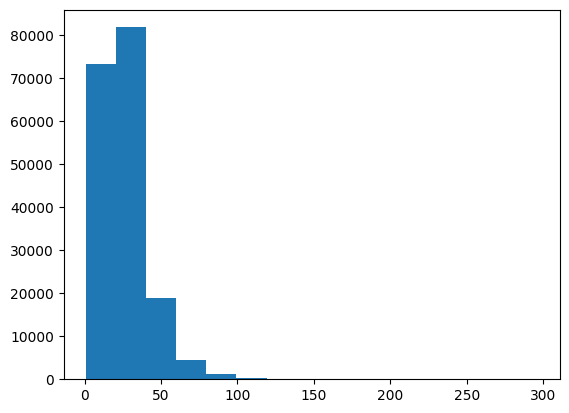

In [51]:
plt.hist(word_lens, bins=15);

In [52]:
np.percentile(word_lens, 95)

np.float64(55.0)

In [53]:
np.percentile(word_lens, 98)

np.float64(68.0)

In [54]:
np.percentile(word_lens, 50)

np.float64(23.0)

In [55]:
#create text vectorizer

In [56]:
from tensorflow.keras import layers

In [57]:
from tensorflow.keras.layers import TextVectorization

In [58]:
max_tokens = 68000 #number from source - https://arxiv.org/pdf/1710.06071

In [59]:
text_vectorizer = layers.TextVectorization(max_tokens=max_tokens, output_sequence_length=55)

In [60]:
text_vectorizer.adapt(train_text)

In [61]:
import random

In [62]:
random_sent = random.choice(train_text)

In [63]:
random_sent

'Taste was rated acceptable for all treatments .'

In [64]:
text_vectorizer(random_sent)

<tf.Tensor: shape=(55,), dtype=int64, numpy=
array([5889,   10, 1888, 1442,   11,   63,  405,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0])>

In [65]:
vocabulary = text_vectorizer.get_vocabulary()

In [66]:
len(vocabulary)

68000

In [67]:
#top 10
vocabulary[:10]

['',
 '[UNK]',
 np.str_('the'),
 np.str_('and'),
 np.str_('of'),
 np.str_('in'),
 np.str_('to'),
 np.str_('with'),
 np.str_('a'),
 np.str_('were')]

In [68]:
#least 10
vocabulary[-10:]

[np.str_('httpswwwanzctrorgautrialregistrationtrialreviewaspxid362489'),
 np.str_('httpswwwanzctrorgautrialregistrationtrialreviewaspxid347505'),
 np.str_('httpswwwanzctrorgautrialregistrationtrialreviewaspxid343307'),
 np.str_('httpswwwanzctrorgautrialregistrationtrialreviewaspxactrn12611000081910'),
 np.str_('httpswwwanzctrorgau'),
 np.str_('httpsuploaduminacjpcgiopenbinctrctrcgifunctionbrowsactionbrowstypesummaryrecptnor000008238languagee'),
 np.str_('httpsregisterclinicaltrialsgov'),
 np.str_('httpsmartmicrosurgerycom'),
 np.str_('httpseudractemaeuropaeuindexhtml'),
 np.str_('httpseudractemaeuropaeu')]

In [69]:
#making embedding layer for making embeddings

In [70]:
embedding = layers.Embedding(input_dim=max_tokens, output_dim=128, mask_zero=True, name="embedding_layer")

In [71]:
random_sent

'Taste was rated acceptable for all treatments .'

In [72]:
embedding(text_vectorizer([random_sent]))

<tf.Tensor: shape=(1, 55, 128), dtype=float32, numpy=
array([[[-0.03843403, -0.03621436, -0.02046154, ...,  0.00307834,
          0.01272409, -0.01269132],
        [-0.01176258,  0.04316909, -0.02235464, ...,  0.01712376,
         -0.03374052, -0.02962983],
        [-0.03862426,  0.01043401,  0.03836328, ...,  0.04507584,
          0.02684819,  0.04054815],
        ...,
        [-0.03251211, -0.02235417, -0.02986594, ...,  0.01043794,
          0.02128797, -0.04624283],
        [-0.03251211, -0.02235417, -0.02986594, ...,  0.01043794,
          0.02128797, -0.04624283],
        [-0.03251211, -0.02235417, -0.02986594, ...,  0.01043794,
          0.02128797, -0.04624283]]], dtype=float32)>

In [73]:
#bulit tf.data for faster process

In [74]:
import tensorflow as tf

In [75]:
train_dataset = tf.data.Dataset.from_tensor_slices((train_text, train_labels)).batch(32).prefetch(tf.data.AUTOTUNE)

In [76]:
test_dataset = tf.data.Dataset.from_tensor_slices((test_text, test_labels)).batch(32).prefetch(tf.data.AUTOTUNE)

In [77]:
valid_dataset = tf.data.Dataset.from_tensor_slices((valid_text, valid_labels)).batch(32).prefetch(tf.data.AUTOTUNE)

In [78]:
train_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None,), dtype=tf.string, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

In [79]:
#bulid first model using tensorflow

In [80]:
inputs = layers.Input(shape=(1,),dtype=tf.string, name='input_layer')

In [81]:
x = text_vectorizer(inputs)

In [82]:
x = embedding(x)

In [83]:
x = layers.Conv1D(128, kernel_size=5, padding='same', activation='relu', name='conv1d')(x)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'conv1d' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


In [84]:
x = layers.GlobalMaxPool1D()(x)

In [85]:
outputs = layers.Dense(5, activation='softmax', name='output_layer')(x)

In [86]:
model_1 = tf.keras.Model(inputs, outputs)

In [87]:
model_1.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 1)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ text_vectorization                   │ (None, 55)                  │               0 │
│ (TextVectorization)                  │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding_layer (Embedding)          │ (None, 55, 128)             │       8,704,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d (Conv1D)                      │ (None, 55, 128)             │          82,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d                 │ (None, 128)                 │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output_layer (Dense)                 │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,786,693 (33.52 MB)

 Trainable params: 8,786,693 (33.52 MB)

 Non-trainable params: 0 (0.00 B)

In [88]:
model_1.compile(loss='sparse_categorical_crossentropy',
                optimizer=tf.keras.optimizers.Adam(),
                metrics=['accuracy'])

In [89]:
history_model_1 = model_1.fit(train_dataset,
                              epochs=3,
                              steps_per_epoch=int(0.1*len(train_dataset)),
                              validation_data=valid_dataset,
                              validation_steps=int(0.1*len(valid_dataset))
                              )


Epoch 1/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.5776 - loss: 1.0630 - val_accuracy: 0.7982 - val_loss: 0.5679
Epoch 2/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.7896 - loss: 0.5798 - val_accuracy: 0.8052 - val_loss: 0.5304
Epoch 3/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.8024 - loss: 0.5300 - val_accuracy: 0.8108 - val_loss: 0.5080


In [90]:
model_1.evaluate(valid_dataset)

945/945 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8119 - loss: 0.5034


[0.5094877481460571, 0.8123593330383301]

In [91]:
model_1_pred_prob = model_1.predict(valid_dataset)

945/945 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [92]:
model_1_pred = tf.argmax(model_1_pred_prob, axis=1)

In [93]:
model_1_pred

<tf.Tensor: shape=(30212,), dtype=int64, numpy=array([0, 1, 3, ..., 4, 4, 1])>

In [94]:
model_1_results = create_model_results(valid_labels, model_1_pred)

In [95]:
model_1_results

{'accuracy': 0.8123593274195684,
 'preciscion': 0.8102957374102518,
 'recall': 0.8123593274195684,
 'f1-score': 0.8110609566634266}

In [96]:
#build model with pre-trained embeddings form tensorflow

In [97]:
import tensorflow_hub as hub

In [98]:
import tf_keras as keras

In [99]:
tf_embeddings = hub.KerasLayer('https://tfhub.dev/google/universal-sentence-encoder/4', trainable=False, name='USE')

In [100]:
inputs = keras.Input(shape=[], dtype=tf.string, name='input_layer')

In [101]:
x = tf_embeddings(inputs)

In [102]:
x = keras.layers.Dense(128, activation='relu', name='dense_layer')(x)

In [103]:
outputs = keras.layers.Dense(5, activation='softmax', name='output_layers')(x)

In [104]:
model_2 = keras.Model(inputs, outputs)

In [105]:
model_2.compile(loss='sparse_categorical_crossentropy',
                optimizer=keras.optimizers.Adam(),
                metrics=['accuracy'])

In [106]:
model_2.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None,)]                 0         
                                                                 
 USE (KerasLayer)            (None, 512)               256797824 
                                                                 
 dense_layer (Dense)         (None, 128)               65664     
                                                                 
 output_layers (Dense)       (None, 5)                 645       
                                                                 
Total params: 256864133 (979.86 MB)
Trainable params: 66309 (259.02 KB)
Non-trainable params: 256797824 (979.61 MB)
_________________________________________________________________


In [107]:
history_model_2 = model_2.fit(train_dataset, epochs=3, steps_per_epoch=int(0.1*len(train_dataset)),
                              validation_data=valid_dataset, validation_steps=int(0.1*len(valid_dataset)))

Epoch 1/3
562/562 [==============================] - 15s 19ms/step - loss: 0.8875 - accuracy: 0.6625 - val_loss: 0.7745 - val_accuracy: 0.6948
Epoch 2/3
562/562 [==============================] - 7s 12ms/step - loss: 0.7440 - accuracy: 0.7106 - val_loss: 0.7328 - val_accuracy: 0.7168
Epoch 3/3
562/562 [==============================] - 8s 15ms/step - loss: 0.7283 - accuracy: 0.7204 - val_loss: 0.7211 - val_accuracy: 0.7128


In [108]:
model_2.evaluate(valid_dataset)

945/945 [==============================] - 11s 11ms/step - loss: 0.7179 - accuracy: 0.7242


[0.7179386615753174, 0.7242486476898193]

In [109]:
model_2_pred_prob = model_2.predict(valid_dataset)

945/945 [==============================] - 11s 11ms/step


In [110]:
model_2_pred = tf.argmax(model_2_pred_prob, axis=1)

In [111]:
model_2_results = create_model_results(valid_labels, model_2_pred)

In [112]:
model_2_results

{'accuracy': 0.7242486429233417,
 'preciscion': 0.7248315250622023,
 'recall': 0.7242486429233417,
 'f1-score': 0.7215641181435288}

In [113]:
#bulid model with character embeddings

In [114]:
def split_chars(text):
  return " ".join(list(text))

In [115]:
train_chars = [split_chars(sentence) for sentence in train_text]

In [116]:
test_chars = [split_chars(sentence) for sentence in test_text]
valid_chars = [split_chars(sentence) for sentence in valid_text]

In [117]:
train_chars[:3]

['T o   i n v e s t i g a t e   t h e   e f f i c a c y   o f   6   w e e k s   o f   d a i l y   l o w - d o s e   o r a l   p r e d n i s o l o n e   i n   i m p r o v i n g   p a i n   ,   m o b i l i t y   ,   a n d   s y s t e m i c   l o w - g r a d e   i n f l a m m a t i o n   i n   t h e   s h o r t   t e r m   a n d   w h e t h e r   t h e   e f f e c t   w o u l d   b e   s u s t a i n e d   a t   1 2   w e e k s   i n   o l d e r   a d u l t s   w i t h   m o d e r a t e   t o   s e v e r e   k n e e   o s t e o a r t h r i t i s   (   O A   )   .',
 'A   t o t a l   o f   1 2 5   p a t i e n t s   w i t h   p r i m a r y   k n e e   O A   w e r e   r a n d o m i z e d   1 : 1   ;   6 3   r e c e i v e d   7 . 5   m g / d a y   o f   p r e d n i s o l o n e   a n d   6 2   r e c e i v e d   p l a c e b o   f o r   6   w e e k s   .',
 'O u t c o m e   m e a s u r e s   i n c l u d e d   p a i n   r e d u c t i o n   a n d   i m p r o v e m e n t   i n   f u n c t i o n   s 

In [118]:
chars_len = [len(sentence) for sentence in train_text]

In [119]:
mean_chars_len = np.mean(chars_len)

In [120]:
mean_chars_len

np.float64(152.006276383026)

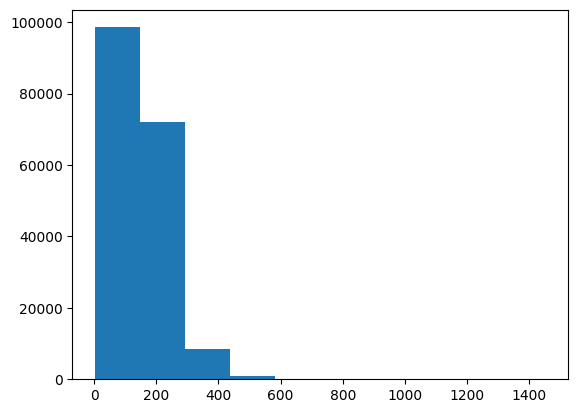

In [121]:
plt.hist(chars_len);

In [122]:
chars_len_95prc = int(np.percentile(chars_len, 95))

In [123]:
chars_len_95prc

296

In [124]:
import string

In [125]:
all_chars = string.ascii_lowercase+string.digits+string.punctuation
all_chars

'abcdefghijklmnopqrstuvwxyz0123456789!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [126]:
len(all_chars)

68

In [127]:
char_vectorizer = TextVectorization(output_sequence_length=chars_len_95prc,
                                    name='character_vectorizer')

In [128]:
char_vectorizer.adapt(train_chars)

In [129]:
char_vocabulary = char_vectorizer.get_vocabulary()

In [130]:
char_vocabulary[:10]

['',
 '[UNK]',
 np.str_('e'),
 np.str_('t'),
 np.str_('i'),
 np.str_('a'),
 np.str_('n'),
 np.str_('o'),
 np.str_('r'),
 np.str_('s')]

In [131]:
char_vocabulary[-10:]

[np.str_('3'),
 np.str_('4'),
 np.str_('x'),
 np.str_('6'),
 np.str_('9'),
 np.str_('8'),
 np.str_('7'),
 np.str_('z'),
 np.str_('q'),
 np.str_('j')]

In [132]:
len(char_vocabulary)

38

In [133]:
#embedding layer

In [134]:
char_embedding = layers.Embedding(input_dim=len(char_vocabulary),
                                  output_dim=25,
                                  mask_zero=True,
                                  name="char_embedding")

In [135]:
embeded_random_sent = char_embedding(char_vectorizer([random_sent]))

In [136]:
random_sent

'Taste was rated acceptable for all treatments .'

In [137]:
embeded_random_sent

<tf.Tensor: shape=(1, 296, 25), dtype=float32, numpy=
array([[[ 4.8440602e-02, -4.7623362e-02, -3.1126214e-02, ...,
          4.2351335e-04,  3.7816260e-02, -4.3009892e-03],
        [ 4.8440602e-02, -4.7623362e-02, -3.1126214e-02, ...,
          4.2351335e-04,  3.7816260e-02, -4.3009892e-03],
        [ 4.8440602e-02, -4.7623362e-02, -3.1126214e-02, ...,
          4.2351335e-04,  3.7816260e-02, -4.3009892e-03],
        ...,
        [-2.0956863e-02, -4.5149054e-02, -6.9625676e-06, ...,
          4.1583490e-02,  1.5875522e-02,  1.3395157e-02],
        [-2.0956863e-02, -4.5149054e-02, -6.9625676e-06, ...,
          4.1583490e-02,  1.5875522e-02,  1.3395157e-02],
        [-2.0956863e-02, -4.5149054e-02, -6.9625676e-06, ...,
          4.1583490e-02,  1.5875522e-02,  1.3395157e-02]]], dtype=float32)>

In [138]:
inputs = layers.Input(shape=(1,), dtype=tf.string, name='input_layer')

In [139]:
x = char_vectorizer(inputs)

In [140]:
x = char_embedding(x)

In [141]:
x = layers.Conv1D(128, kernel_size=5, padding='same', activation='relu', name='conv1d_layer')(x)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'conv1d_layer' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


In [142]:
x = layers.GlobalMaxPool1D()(x)

In [143]:
outputs = layers.Dense(5, activation='softmax', name='output_layer')(x)

In [144]:
model_3 = tf.keras.Model(inputs, outputs)

In [145]:
model_3.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 1)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ character_vectorizer                 │ (None, 296)                 │               0 │
│ (TextVectorization)                  │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ char_embedding (Embedding)           │ (None, 296, 25)             │             950 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_layer (Conv1D)                │ (None, 296, 128)            │          16,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d_1               │ (None, 128)                 │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output_layer (Dense)                 │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,723 (69.23 KB)

 Trainable params: 17,723 (69.23 KB)

 Non-trainable params: 0 (0.00 B)

In [146]:
model_3.compile(loss='sparse_categorical_crossentropy',
                optimizer=tf.keras.optimizers.Adam(),
                metrics=['accuracy'])

In [147]:
train_char_dataset = tf.data.Dataset.from_tensor_slices((train_chars, train_labels)).batch(32).prefetch(tf.data.AUTOTUNE)
test_char_dataset = tf.data.Dataset.from_tensor_slices((test_chars, test_labels)).batch(32).prefetch(tf.data.AUTOTUNE)
valid_char_dataset = tf.data.Dataset.from_tensor_slices((valid_chars, valid_labels)).batch(32).prefetch(tf.data.AUTOTUNE)

In [148]:
history_model_3 = model_3.fit(train_char_dataset,
                              epochs=3,
                              steps_per_epoch=int(0.1*len(train_char_dataset)),
                              validation_data=valid_char_dataset,
                              validation_steps=int(0.1*len(valid_char_dataset)))

Epoch 1/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4551 - loss: 1.3248 - val_accuracy: 0.6536 - val_loss: 0.9052
Epoch 2/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6429 - loss: 0.8970 - val_accuracy: 0.6835 - val_loss: 0.8074
Epoch 3/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6907 - loss: 0.8021 - val_accuracy: 0.7071 - val_loss: 0.7590


In [149]:
model_3.evaluate(valid_char_dataset)

945/945 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6995 - loss: 0.7649


[0.7660641670227051, 0.6999867558479309]

In [150]:
model_3_pred_prob = model_3.predict(valid_char_dataset)

945/945 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


In [151]:
model_3_pred = tf.argmax(model_3_pred_prob, axis=1)

In [152]:
model_3_pred [:10]

<tf.Tensor: shape=(10,), dtype=int64, numpy=array([1, 1, 3, 2, 4, 2, 2, 3, 4, 1])>

In [153]:
model_3_results = create_model_results(valid_labels, model_3_pred)
model_3_results

{'accuracy': 0.6999867602277241,
 'preciscion': 0.70619130315072,
 'recall': 0.6999867602277241,
 'f1-score': 0.6895725730334294}

In [154]:
#traing replicate paper's model https://arxiv.org/pdf/1612.05251

In [155]:
#first step - embedding model using USE from tensorflow

In [156]:
embed = hub.KerasLayer('https://tfhub.dev/google/universal-sentence-encoder/4', trainable=False, name='USE')

In [206]:
embed_inputs = keras.Input(shape=[], dtype=tf.string, name='input_embedding_layer')
embed_layer = embed(embed_inputs)
embed_outputs = keras.layers.Dense(128, activation='relu', name='dense_embedding_layer')(embed_layer)
embed_model = keras.Model(embed_inputs, embed_outputs)

In [158]:
#second step - character embedding model

In [308]:
char_vectorizer = keras.layers.TextVectorization(output_sequence_length=chars_len_95prc,
                                    name='character_vectorizer')

In [309]:
char_vectorizer.adapt(train_chars)

In [310]:
char_embed = keras.layers.Embedding(input_dim=len(char_vocabulary),
                                  output_dim=25,
                                  mask_zero=True,
                                  name="char_embedding")

In [207]:
char_inputs = keras.Input(shape=(1,), dtype=tf.string, name='input_char_layer')
char_vect_layer = char_vectorizer(char_inputs)
char_embed_layer = char_embed(char_vect_layer)
char_embed_lstm_layer = keras.layers.Bidirectional(keras.layers.LSTM(64, return_sequences=True), name='bi-LSTM_char_layer')(char_embed_layer)
char_outputs = keras.layers.Bidirectional(keras.layers.LSTM(64), name='outputs_char_layer')(char_embed_lstm_layer)
char_model = keras.Model(char_inputs, char_outputs)

In [162]:
#third step - concatenate two models as inputs for bi-LSTM model

In [208]:
concatenate_layer = keras.layers.Concatenate(name='concatenate_layer')([embed_model.output, char_model.output])

In [164]:
#last step - build combined model

In [260]:
x = keras.layers.Dropout(0.5)(concatenate_layer)
x = keras.layers.Dense(128, activation='relu', name='dense_layer')(x)
x = keras.layers.Dropout(0.5)(x)
outputs = keras.layers.Dense(5, activation='softmax', name='outputs_layer')(x)
model_4 = keras.Model(inputs=[embed_model.input, char_model.input], outputs=outputs)

In [210]:
model_4.summary()

Model: "model_8"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_char_layer (InputLay  [(None, 1)]                  0         []                            
 er)                                                                                              
                                                                                                  
 character_vectorizer (Text  (None, 296)                  0         ['input_char_layer[0][0]']    
 Vectorization)                                                                                   
                                                                                                  
 input_embedding_layer (Inp  [(None,)]                    0         []                            
 utLayer)                                                                                   

In [211]:
model_4.compile(loss='sparse_categorical_crossentropy',
                optimizer=keras.optimizers.Adam(),
                metrics=['accuracy'])

In [196]:
train_mix_data = tf.data.Dataset.from_tensor_slices((train_text, train_chars))

In [197]:
train_mix_labels = tf.data.Dataset.from_tensor_slices(train_labels)

In [198]:
train_mix_dataset = tf.data.Dataset.zip(train_mix_data, train_mix_labels)

In [199]:
train_mix_dataset = train_mix_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

In [200]:
valid_mix_data = tf.data.Dataset.from_tensor_slices((valid_text, valid_chars))
valid_mix_labels = tf.data.Dataset.from_tensor_slices(valid_labels)
valid_mix_dataset = tf.data.Dataset.zip(valid_mix_data, valid_mix_labels)
valid_mix_dataset = valid_mix_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

In [201]:
test_mix_data = tf.data.Dataset.from_tensor_slices((test_text, test_chars))
test_mix_labels = tf.data.Dataset.from_tensor_slices(test_labels)
test_mix_dataset = tf.data.Dataset.zip(test_mix_data, test_mix_labels)
test_mix_dataset = test_mix_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

In [212]:
history_model_4 = model_4.fit(train_mix_dataset,
                              epochs=3,
                              steps_per_epoch=int(0.1*len(train_mix_dataset)),
                              validation_data=valid_mix_dataset,
                              validation_steps=int(0.1*len(valid_mix_dataset)))

Epoch 1/3
562/562 [==============================] - 86s 119ms/step - loss: 0.9665 - accuracy: 0.6139 - val_loss: 0.7630 - val_accuracy: 0.6975
Epoch 2/3
562/562 [==============================] - 44s 78ms/step - loss: 0.7793 - accuracy: 0.6994 - val_loss: 0.7011 - val_accuracy: 0.7274
Epoch 3/3
562/562 [==============================] - 35s 62ms/step - loss: 0.7532 - accuracy: 0.7107 - val_loss: 0.6850 - val_accuracy: 0.7397


In [213]:
model_4.evaluate(valid_mix_dataset)

945/945 [==============================] - 27s 28ms/step - loss: 0.6836 - accuracy: 0.7391


[0.6836130023002625, 0.7390772104263306]

In [214]:
model_4_pred_prob = model_4.predict(valid_mix_dataset)

945/945 [==============================] - 34s 28ms/step


In [218]:
model_4_pred = tf.argmax(model_4_pred_prob, axis=1)

In [219]:
model_4_pred

<tf.Tensor: shape=(30212,), dtype=int64, numpy=array([0, 1, 3, ..., 4, 4, 1])>

In [220]:
model_4_results = create_model_results(valid_labels, model_4_pred)
model_4_results

{'accuracy': 0.7390771878723686,
 'preciscion': 0.7422122415399398,
 'recall': 0.7390771878723686,
 'f1-score': 0.7363431409853753}

In [ ]:
#rtraing to add positionalembeddings - add info about number of sentences

In [222]:
train_df.head(10)

,target,text,line_number,total_lines
0,OBJECTIVE,To investigate the efficacy of 6 weeks of dail...,0,11
1,METHODS,A total of 125 patients with primary knee OA w...,1,11
2,METHODS,Outcome measures included pain reduction and i...,2,11
3,METHODS,Pain was assessed using the visual analog pain...,3,11
4,METHODS,Secondary outcome measures included the Wester...,4,11
5,METHODS,"Serum levels of interleukin 1 ( IL-1 ) , IL-6 ...",5,11
6,RESULTS,There was a clinically relevant reduction in t...,6,11
7,RESULTS,The mean difference between treatment arms ( 9...,7,11
8,RESULTS,"Further , there was a clinically relevant redu...",8,11
9,RESULTS,These differences remained significant at 12 w...,9,11


In [223]:
train_df['line_number'].value_counts()

,count
line_number,
0,15000
1,15000
2,15000
3,15000
4,14992
5,14949
6,14758
7,14279
8,13346


In [224]:
train_df['total_lines'].value_counts()

,count
total_lines,
11,24468
10,23639
12,22113
9,19400
13,18438
14,14610
8,12285
15,10768
7,7464


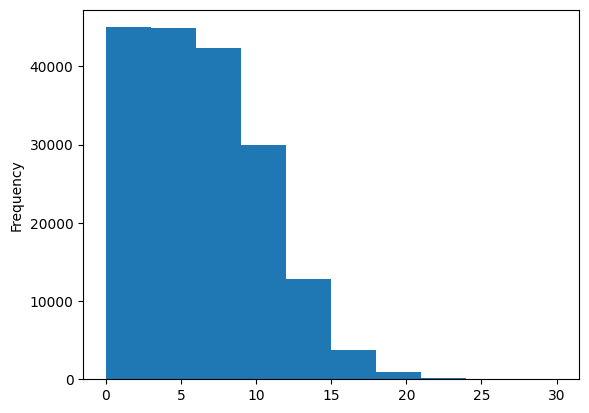

In [225]:
train_df['line_number'].plot.hist();

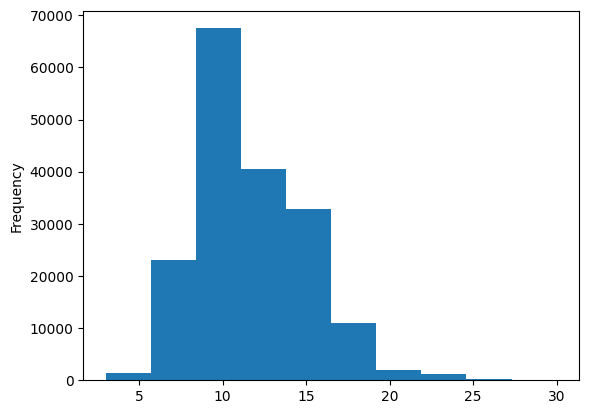

In [226]:
train_df['total_lines'].plot.hist();

In [242]:
np.percentile(train_df['line_number'], 99)

np.float64(17.0)

In [243]:
np.percentile(train_df['total_lines'], 99)

np.float64(21.0)

In [233]:
encoder_line_number = OneHotEncoder(max_categories=17,sparse_output=False)

In [246]:
train_ohe_line_number = encoder_line_number.fit_transform(train_df['line_number'].to_numpy().reshape(-1,1))

In [292]:
test_ohe_line_number = encoder_line_number.transform(test_df['line_number'].to_numpy().reshape(-1,1))
valid_ohe_line_number = encoder_line_number.transform(valid_df['line_number'].to_numpy().reshape(-1,1))

In [244]:
encoder_total_lines = OneHotEncoder(max_categories=21,sparse_output=False)

In [286]:
train_ohe_total_lines = encoder_total_lines.fit_transform(train_df['total_lines'].to_numpy().reshape(-1,1))

In [248]:
test_ohe_total_lines = encoder_total_lines.transform(test_df['total_lines'].to_numpy().reshape(-1,1))
valid_ohe_total_lines = encoder_total_lines.transform(valid_df['total_lines'].to_numpy().reshape(-1,1))

In [249]:
#build models

In [251]:
embed_inputs = keras.Input(shape=[], dtype=tf.string, name='input_embed_layer')
embed_layer = embed(embed_inputs)
embed_outputs = keras.layers.Dense(128, activation='relu', name='output_embed_layer')(embed_layer)
embed_model = keras.Model(embed_inputs, embed_outputs)

In [271]:
char_embed = keras.layers.Embedding(input_dim=len(char_vocabulary),
                                  output_dim=25,
                                  mask_zero=True,
                                  name="char_embedding")

In [311]:
char_inputs = keras.Input(shape=(1,), dtype=tf.string, name='input_char_layer')
char_vect_layer = char_vectorizer(char_inputs)
char_embed_layer = char_embed(char_vect_layer)
char_embed_lstm_layer = keras.layers.Bidirectional(keras.layers.LSTM(64, return_sequences=True), name='bi-lstm_layer')(char_embed_layer)
char_outputs = keras.layers.Bidirectional(keras.layers.LSTM(64), name='outputs_char_layer')(char_embed_lstm_layer)
char_model = keras.Model(char_inputs, char_outputs)

In [312]:
line_number_inputs = keras.layers.Input(shape=(17,), dtype=tf.int32, name='line_number_layer')
line_number_outputs = keras.layers.Dense(64, activation='relu')(line_number_inputs)
line_number_model = keras.Model(line_number_inputs, line_number_outputs)

In [313]:
total_lines_inputs = keras.layers.Input(shape=(21,), dtype=tf.int32, name='total_lines_layer')
total_lines_outputs = keras.layers.Dense(64, activation='relu')(total_lines_inputs)
total_lines_model = keras.Model(total_lines_inputs, total_lines_outputs)

In [259]:
#concatenate all models

In [314]:
concatenate_layer = keras.layers.Concatenate(name='concatenate_layer_1')([embed_model.output, char_model.output])

In [315]:
x = keras.layers.Dropout(0.5)(concatenate_layer)
x = keras.layers.Dense(128, activation='relu', name='dense_layer')(x)
x = keras.layers.Dropout(0.5)(x)

In [262]:
x.shape

TensorShape([None, 128])

In [263]:
line_number_model.output.shape

TensorShape([None, 64])

In [265]:
total_lines_model.output.shape

TensorShape([None, 64])

In [316]:
concatenate_layer_2 = keras.layers.Concatenate(name='concatenate_layer_2')([line_number_model.output, total_lines_model.output, x])

In [317]:
outputs = keras.layers.Dense(5, activation='softmax', name='outputs_layer')(concatenate_layer_2)

In [318]:
model_5 = keras.Model(inputs=[embed_model.input, char_model.input, line_number_model.input, total_lines_model.input], outputs=outputs)

In [319]:
model_5.summary()

Model: "model_22"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_char_layer (InputLay  [(None, 1)]                  0         []                            
 er)                                                                                              
                                                                                                  
 character_vectorizer (Text  (None, 296)                  0         ['input_char_layer[0][0]']    
 Vectorization)                                                                                   
                                                                                                  
 input_embed_layer (InputLa  [(None,)]                    0         []                            
 yer)                                                                                      

In [332]:
model_5.compile(loss='sparse_categorical_crossentropy',
                optimizer=keras.optimizers.Adam(),
                metrics=['accuracy'])

In [325]:
train_all_data = tf.data.Dataset.from_tensor_slices((train_text,
                                                     train_chars,
                                                     train_ohe_line_number,
                                                     train_ohe_total_lines))

In [326]:
train_all_labels = tf.data.Dataset.from_tensor_slices(train_labels)

In [327]:
train_all_dataset = tf.data.Dataset.zip((train_all_data, train_all_labels))

In [328]:
train_all_dataset = train_all_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

In [329]:
test_all_data = tf.data.Dataset.from_tensor_slices((test_text,
                                                     test_chars,
                                                     test_ohe_line_number,
                                                     test_ohe_total_lines))
test_all_labels = tf.data.Dataset.from_tensor_slices(test_labels)
test_all_dataset = tf.data.Dataset.zip((test_all_data, test_all_labels))
test_all_dataset = test_all_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

In [330]:
valid_all_data = tf.data.Dataset.from_tensor_slices((valid_text,
                                                     valid_chars,
                                                     valid_ohe_line_number,
                                                     valid_ohe_total_lines))
valid_all_labels = tf.data.Dataset.from_tensor_slices(valid_labels)
valid_all_dataset = tf.data.Dataset.zip((valid_all_data, valid_all_labels))
valid_all_dataset = valid_all_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

In [333]:
history_model_5 = model_5.fit(train_all_dataset,
                              epochs=3,
                              steps_per_epoch=int(0.1 * len(train_all_dataset)),
                              validation_data=valid_all_dataset,
                              validation_steps=int(0.1 * len(valid_all_dataset)))

Epoch 1/3
562/562 [==============================] - 63s 74ms/step - loss: 0.7708 - accuracy: 0.7027 - val_loss: 0.5193 - val_accuracy: 0.8009
Epoch 2/3
562/562 [==============================] - 57s 101ms/step - loss: 0.5091 - accuracy: 0.8059 - val_loss: 0.4479 - val_accuracy: 0.8268
Epoch 3/3
562/562 [==============================] - 49s 86ms/step - loss: 0.4638 - accuracy: 0.8198 - val_loss: 0.4369 - val_accuracy: 0.8305


In [334]:
model_5.evaluate(valid_all_dataset)

945/945 [==============================] - 45s 48ms/step - loss: 0.4316 - accuracy: 0.8318


[0.43155616521835327, 0.8318217992782593]

In [335]:
model_5_pred_prob = model_5.predict(valid_all_dataset)

945/945 [==============================] - 39s 32ms/step


In [336]:
model_5_pred = tf.argmax(model_5_pred_prob, axis=1)

In [337]:
model_5_results = create_model_results(valid_labels, model_5_pred)
model_5_results

{'accuracy': 0.8318217926651662,
 'preciscion': 0.832110504508196,
 'recall': 0.8318217926651662,
 'f1-score': 0.8316090761678331}

In [343]:
all_restults = pd.DataFrame({'baseline': baseline_results,
                             'Conv1D_model': model_1_results,
                             'USE_model': model_2_results,
                             'char_Conv1D_model': model_3_results,
                             'papers_model': model_4_results,
                             'final_model': model_5_results})

In [346]:
all_restults = all_restults.T

In [347]:
all_restults

,accuracy,preciscion,recall,f1-score
baseline,0.731729,0.731517,0.731729,0.705806
Conv1D_model,0.812359,0.810296,0.812359,0.811061
USE_model,0.724249,0.724832,0.724249,0.721564
char_Conv1D_model,0.699987,0.706191,0.699987,0.689573
papers_model,0.739077,0.742212,0.739077,0.736343
final_model,0.831822,0.832111,0.831822,0.831609


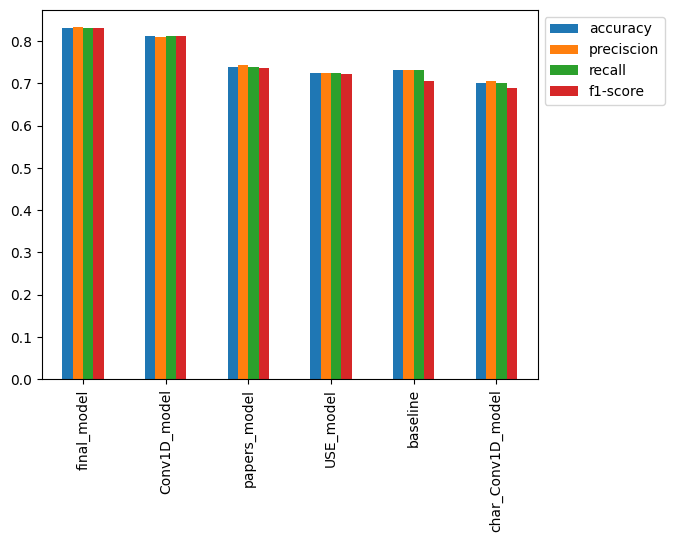

In [354]:
all_restults.sort_values('f1-score', ascending=False).plot.bar().legend(bbox_to_anchor=(1.0,1.0));

In [356]:
model_5.save('final_NLP_model')

In [357]:
test_pred_prob = model_5.predict(test_all_dataset)

942/942 [==============================] - 47s 50ms/step


In [358]:
test_pred = tf.argmax(test_pred_prob, axis=1)

In [359]:
create_model_results(test_labels, test_pred)

{'accuracy': 0.8287373485979758,
 'preciscion': 0.8298386995124716,
 'recall': 0.8287373485979758,
 'f1-score': 0.8285731639162744}